In [20]:
import numpy as np
from fractions import Fraction
from math import gcd

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT, Initialize, PhaseEstimation, UnitaryGate, RYGate,PauliEvolutionGate
from qiskit.circuit import *
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp

In [21]:
A = np.array([[1,-1/3], [-1/3,1]])
b = np.array([0,1])
solution = np.linalg.inv(A).dot(b)
print("(debug) Solution(x): ", solution)
print("(debug) Solution ratio: ", (solution[0]/solution[1])**2, "or",  (solution[1]/solution[0])**2)
eigenvalues, eigenvectors = np.linalg.eigh(A)
print("(debug) Eigenvalues: ", eigenvalues)

(debug) Solution(x):  [0.375 1.125]
(debug) Solution ratio:  0.1111111111111111 or 9.0
(debug) Eigenvalues:  [0.66666667 1.33333333]


In [27]:
# get integer ratio of eigenvalues of matrix
def integer_eigenvalue_ratios(matrix):
    # get eigenvalues
    eigenvalues = np.linalg.eigvals(matrix)
    numbers = np.abs(eigenvalues)

    # get gcd
    fractions = [Fraction(num).limit_denominator() for num in numbers]
    denominators = [frac.denominator for frac in fractions]
    lcm_denominator = denominators[0]
    for denom in denominators[1:]:
        lcm_denominator = lcm_denominator * denom // gcd(lcm_denominator, denom)
    integer_ratios = [frac.numerator * (lcm_denominator // frac.denominator) for frac in fractions]
    common_divisor = gcd(*integer_ratios)
    integer_ratios = [num // common_divisor for num in integer_ratios]

    return integer_ratios

print("(debug) Eigenvalue ratio: ", integer_eigenvalue_ratios(A))

def eigenvalue_ratios(count):
    # get eigenvalues
    print(count)
    numbers = [count['01'], count['11']]
    
    # get gcd
    fractions = [Fraction(num).limit_denominator() for num in numbers]
    denominators = [frac.denominator for frac in fractions]
    lcm_denominator = denominators[0]
    for denom in denominators[1:]:
        lcm_denominator = lcm_denominator * denom // gcd(lcm_denominator, denom)
    integer_ratios = [frac.numerator * (lcm_denominator // frac.denominator) for frac in fractions]
    common_divisor = gcd(*integer_ratios)
    integer_ratios = [num // common_divisor for num in integer_ratios]
    integer_ratios = np.array(integer_ratios)
    return integer_ratios


(debug) Eigenvalue ratio:  [2, 1]


In [28]:
# b vector
def initialize_state(qc, q, b, n):
    if b[1] != 0:
        theta = 2*np.arccos(b[0])
        qc.ry(theta, q[n-1])

In [29]:
# get binary idx of max bit n
def get_binary_indices(integer, n):
    binary_string = f"{integer:0{n}b}"[-n:]
    binary_list = [int(bit) for bit in binary_string]
    return binary_list

/tmp/ipykernel_47602/3110076233.py:59: DeprecationWarning: The class ``qiskit.circuit.library.phase_estimation.PhaseEstimation`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.phase_estimation instead.
  qc.compose(PhaseEstimation(n, unitary, name = "QPE"),q[:]+b_vec[:], inplace =True)
/tmp/ipykernel_47602/3110076233.py:66: DeprecationWarning: The class ``qiskit.circuit.library.phase_estimation.PhaseEstimation`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.phase_estimation instead.
  qc.compose(PhaseEstimation(n, unitary, name = "IQPE").inverse(),q[:]+b_vec[:], inplace =True)


Result: 
Measurement:  {'11': 910, '00': 937, '10': 70, '01': 83}
x:  10.963855421686747
{'11': 910, '00': 937, '10': 70, '01': 83}
C: 1
x:  10.833333333333334
{'11': 910, '00': 936, '10': 70, '01': 84}
C: 1
x:  9.39795918367347
{'11': 921, '00': 922, '10': 59, '01': 98}
C: 1
x:  9.303030303030303
{'11': 921, '00': 921, '10': 59, '01': 99}
C: 1
x:  9.03921568627451
{'11': 922, '00': 918, '10': 58, '01': 102}
C: 1
x:  8.96116504854369
{'11': 923, '00': 917, '10': 57, '01': 103}
C: 1
x:  8.96116504854369
x achieved tol


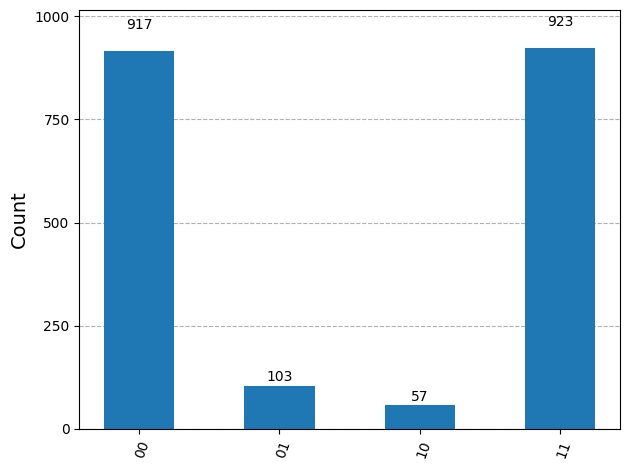

In [45]:
# 고유값 역변환 구현
def eigenvalue_inversion(qc, q, anc, eigenvalues):
    # to get theta(c), we compute the eq of c0,c1,...cn-1
    A = []
    b = []
    
    # to get theta of c0,c1,...cn-1
    if eigenvalues is None:
        for i in range(len(q)):
            theta = 2*np.arcsin(1/2**(1-i))
            qc.cry(theta, q[i], anc)
        return
    for i in range(len(q)):
        C = min(eigenvalues) # to maximize the probability of ancilla bit == 1
        theta = 2*np.arcsin(C/eigenvalues[i])
        qc.cry(theta, q[i], anc)


def Pauli_evolution():
    # Generalization X
    X = SparsePauliOp("X")
    I = SparsePauliOp("I")
    operator = I- (1/3) * X
    evo = PauliEvolutionGate(operator, time=3*np.pi/4)
    return evo


# HHL 알고리즘 구현
def HHL_algorithm(A,b,n,eigen_val=None):
    N = A.shape[0]  # Matrix dimension
    n_qubits = int(np.ceil(np.log2(n)))  # Number of qubits needed
    m = b.shape[0]
    m_qubits = int(np.ceil(np.log2(m)))

    # Create Quantum and Classical Registers
    anc = QuantumRegister(1, 'ancilla')
    q = QuantumRegister(n,'q')
    b_vec = QuantumRegister(m_qubits, 'b_vec')
    c = ClassicalRegister(m_qubits+1,'c')
    qc = QuantumCircuit(anc, q,b_vec, c)

    # Initialize the state |b>
    initialize_state(qc, b_vec, b, m_qubits)

    # Define the unitary operator exp(iAt) for QPE
    eigenvalues, eigenvectors = np.linalg.eigh(A)
    eigenvalue = np.array(integer_eigenvalue_ratios(A))
    # eigenvalues_tilda = eigenvalue*np.pi/2
    # exp_eigenvalues = np.exp(1j*eigenvalues_tilda)
    # exp_diag_matrix = np.diag(exp_eigenvalues)
    # matrix = eigenvectors @ exp_diag_matrix @ (eigenvectors.conj().T)
    # unitary = UnitaryGate(matrix)
    
    if eigen_val is None:
        unitary = Pauli_evolution()

    # Apply QPE
    #qc.compose(qpe(qc, q, b_vec, n, unitary),inplace = True)
    qc.compose(PhaseEstimation(n, unitary, name = "QPE"),q[:]+b_vec[:], inplace =True)
    
    # Apply eigenvalue inversion
    eigenvalue_inversion(qc, q, anc, eigenvalues = eigen_val)

    # Apply inverse QPE
    qc.measure(anc,c[0])
    qc.compose(PhaseEstimation(n, unitary, name = "IQPE").inverse(),q[:]+b_vec[:], inplace =True)

    # Measure the first n_qubits
    qc.measure(b_vec,c[1:])

    # Execute the circuit
    
    #service = QiskitRuntimeService(channel = "ibm_cloud", instance='crn:v1:bluemix:public:quantum-computing:eu-de:a/624a449c58db4cebbbcd6d44cd96889e:84f0afd8-a97d-449f-ade8-8c52ea820862::',token ='K0PEGDVYKanigiiNbsvE9jBXCoMksSlj5FP23ULkBKgx')
    #backend = service.backend("ibm_aachen")
    aer_sim = AerSimulator()

    #pass_manager = generate_preset_pass_manager(optimization_level=3, backend=backend)
    pass_manager = generate_preset_pass_manager(optimization_level=3, backend=aer_sim)
    isa_circuit = pass_manager.run(qc)

    #sampler = Sampler(mode=backend)
    sampler = Sampler(mode=aer_sim)
    job = sampler.run([isa_circuit], shots=2000)
    result = job.result()

    result= result[0].data.c.get_counts()
    return result,qc

def con_rec(count):
    # lambda1, lambda2 구하기
    lambda2, lambda1 = eigenvalue_ratios(count)
    
    # C = min(lambda1, lambda2) - 0.1
    C = 1
    print(f"C: {C}")
    # num_00 = count["00"]
    # num_10 = count["10"]
    # X_ratio_by_0a = (num_10/num_00) / ((lambda1**2 / C**2 - 1) / (lambda2**2 / C**2 - 1))

    # num_01 = count["01"]
    # num_11 = count["11"]
    # X_ratio_by_1a = num_11 / num_01

    from00_to01 = int(count["00"] * (1 / (lambda1**2/C**2 - 1)**0.5))
    from10_to11 = int(count["10"] * (1 / (lambda2**2/C**2 - 1)**0.5))
    count["00"] -= from00_to01
    count["01"] += from00_to01
    count["10"] -= from10_to11
    count["11"] += from10_to11

    return count

# 실행
max_iter = 20
# eigenvalues, eigenvectors = np.linalg.eigh(A)
eigen_val = None
x_diff_tol = 1e-3

count ,circuit= HHL_algorithm(A, b, 2, eigen_val)
print("Result: ")
print("Measurement: ",count)
print("x: ",count['11']/count['01'])

pre_x = count['11']/count['01']
for _ in range(max_iter):
    # stop condition; is x converge:
    count = con_rec(count)
    present_x = count['11']/count['01']
    print("x: ", present_x)    
    x_diff = np.abs(present_x - pre_x)
    if x_diff < x_diff_tol:
        print("x achieved tol")
        break
    pre_x = present_x

plot_histogram(count)

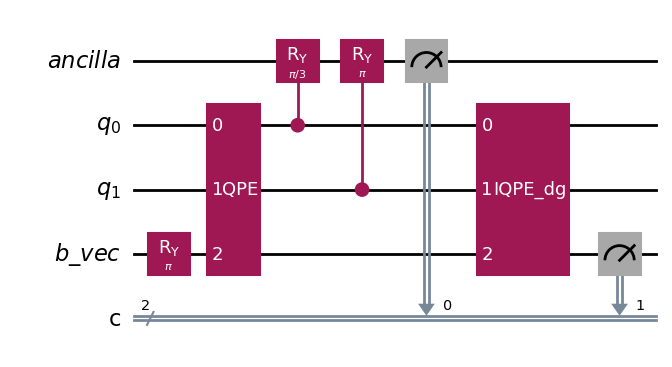

In [31]:
circuit.draw("mpl")

In [32]:
import random
from collections import Counter

def flip(string, num, probability):
    str_list = list(string)
    bit_list = []
    weight_list = []
    whole_pro = 0
    len_of_str = len(string)

    for idx, bit in enumerate(reversed(str_list)):
        new_list = []

        # bit_list for random flip
        new_list = str_list
        new_list[len_of_str - idx - 1] = str(1 - int(bit))
        new_str = "".join(new_list)
        bit_list.append(new_str)

        # weight_list for random flip
        key_first = chr(ord('a')+idx)
        key = "".join([key_first, bit, str(1 - int(bit))])
        current_pro = probability[key]
        weight_list.append(current_pro)
        whole_pro += current_pro
    
    bit_list.append(string)
    weight_list.append(1-whole_pro)

    results = random.choices(bit_list, weights=weight_list, k=num)
    return Counter(results)

def config_recov(data, pro, upper_bound, lower_bound):
    ccount = dict()
    current_count = dict()
    
    for k, v in data.items():
        if v >= lower_bound and v <= upper_bound:
            current_count[k] = v
        else:
            current_count = flip(k, v, pro)
        for k1, v1 in current_count.items():
            if k1 not in ccount:
                ccount[k1] = v1
            else:
                ccount[k1] += v1
    
    return ccount

def HHL_measure(data, iteration, max_iteration, measure_tol, ratio_a, probability=None):
    if probability == None:
        probability["a01"] = 0.01
        probability["a10"] = 0.01
        probability["b01"] = 0.01
        probability["b10"] = 0.01
    standard_line = iteration / ((1+ratio_a) * 2)
    upper_bound = standard_line*(1+measure_tol)
    lower_bound = standard_line*(1-measure_tol)
    print(standard_line, standard_line*(1-measure_tol), standard_line*(1+measure_tol))
    print(data)
    current_result = dict()
    for _ in range(max_iteration):
        current_result = config_recov(data, probability, upper_bound, lower_bound)

        if current_result["00"] >= lower_bound and current_result["00"] <= upper_bound and current_result["10"] >= lower_bound and current_result["10"] <= upper_bound:
            print("converged!")
            break
        
        data = current_result
        print(current_result)

    print(current_result)
    return current_result

probability = {'a01': 0.01, 'a10': 0.01, 'b01': 0.05, 'b10': 0.01}

data = count

lst = HHL_measure(data, 50000, 5, 0.03, 1.66, probability)

9398.496240601504 9116.541353383458 9680.45112781955
{'11': -3324, '10': 4356, '00': 749, '01': 219}
{'10': 4278, '01': 247, '11': 89, '00': 710}
{'11': 173, '10': 4197, '01': 297, '00': 657}
{'11': 266, '00': 611, '10': 4120, '01': 327}
{'11': 315, '10': 4071, '00': 590, '01': 348}
{'11': 381, '10': 4009, '00': 559, '01': 375}
{'11': 381, '10': 4009, '00': 559, '01': 375}
